In [ ]:
# ==========================================
# CELL 1: CORRECT C4 → Cn Volterra Geometry
# ==========================================

import meep as mp
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# PARAMETERS
# -----------------------------
a = 1.0
r_hole = 0.27 * a
offset = 0.3 * a
eps_bg = 3.42**2

Rmax = 3
cavity_radius = 4.0
cell_size = 8

n = 6      # target symmetry (works for 3,4,5,6,...)
c = 0    # core pull parameter

# -----------------------------
# C4 basis
# -----------------------------
c4_basis = [
    (+offset, +offset),
    (+offset, -offset),
    (-offset, +offset),
    (-offset, -offset),
]

# -----------------------------
# Build C4 lattice
# -----------------------------
c4_points = []

for i in range(-Rmax, Rmax+1):
    for j in range(-Rmax, Rmax+1):
        for dx, dy in c4_basis:
            x = i*a + dx
            y = j*a + dy
            if np.sqrt(x**2 + y**2) < cavity_radius:
                c4_points.append((x, y))

# -----------------------------
# Extend angular domain properly
# -----------------------------
extended = []

for x, y in c4_points:

    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    if theta < 0:
        theta += 2*np.pi

    # create n-3 angular sheets (including original)
    for k in range(n-3):
        theta_k = theta + k*2*np.pi
        extended.append((r, theta_k))

# -----------------------------
# Compress back to 2π
# θ' = (4/n) θ
# -----------------------------
cN_points = []

for r, theta in extended:
    theta_new = (4/n) * theta
    x_new = r*np.cos(theta_new)
    y_new = r*np.sin(theta_new)
    if r < cavity_radius:
        cN_points.append((x_new, y_new))

# Remove duplicates (important!)
coords = np.unique(np.round(cN_points, decimals=6), axis=0)

# -----------------------------
# Pull n nearest holes inward
# -----------------------------
distances = np.linalg.norm(coords, axis=1)
nearest_indices = np.argsort(distances)[:n]

for idx in nearest_indices:
    r = distances[idx]
    theta = np.arctan2(coords[idx,1], coords[idx,0])
    r_new = (1 - c)*r
    coords[idx,0] = r_new*np.cos(theta)
    coords[idx,1] = r_new*np.sin(theta)

# -----------------------------
# Convert to Meep geometry
# -----------------------------
geometry_cN = [
    mp.Cylinder(
        r_hole,
        height=mp.inf,
        center=mp.Vector3(x, y),
        material=mp.Medium(epsilon=1),
    )
    for (x, y) in coords
]

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(6,6))
plt.scatter(coords[:,0], coords[:,1], s=35)
plt.gca().set_aspect("equal")
plt.title(f"C{n} Disclination (c = {c})")
plt.xlim(-cell_size/2, cell_size/2)
plt.ylim(-cell_size/2, cell_size/2)
plt.show()

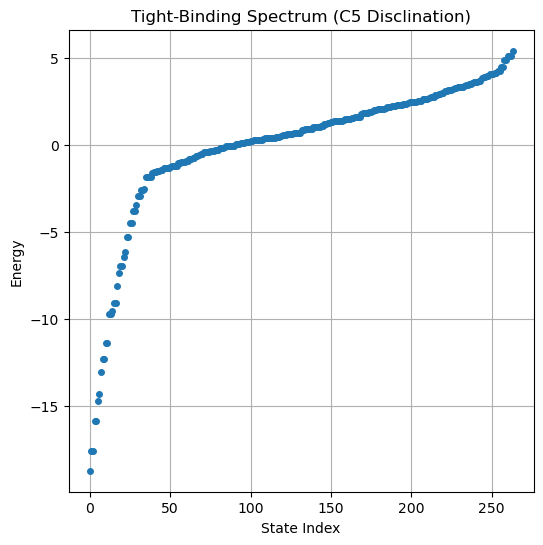

In [35]:
# ==========================================
# CELL 2: Tight-Binding Calculation
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

# -----------------------------
# PARAMETERS
# -----------------------------
t = 1.0           # hopping strength
onsite = 0.0      # onsite energy
cutoff = 1.05     # nearest-neighbor threshold

N = len(coords)
H = np.zeros((N,N))

# On-site
np.fill_diagonal(H, onsite)

# Hopping
for i in range(N):
    for j in range(i+1, N):
        dist = np.linalg.norm(coords[i] - coords[j])
        if dist < cutoff:
            H[i,j] = -t
            H[j,i] = -t

# -----------------------------
# Diagonalize
# -----------------------------
energies, states = eigh(H)

# -----------------------------
# Plot Energy vs State Index
# -----------------------------
plt.figure(figsize=(6,6))
plt.plot(range(N), energies, 'o', markersize=4)
plt.xlabel("State Index")
plt.ylabel("Energy")
plt.title("Tight-Binding Spectrum (C5 Disclination)")
plt.grid(True)
plt.show()

Saved GIF: energy_vs_state_offset.gif


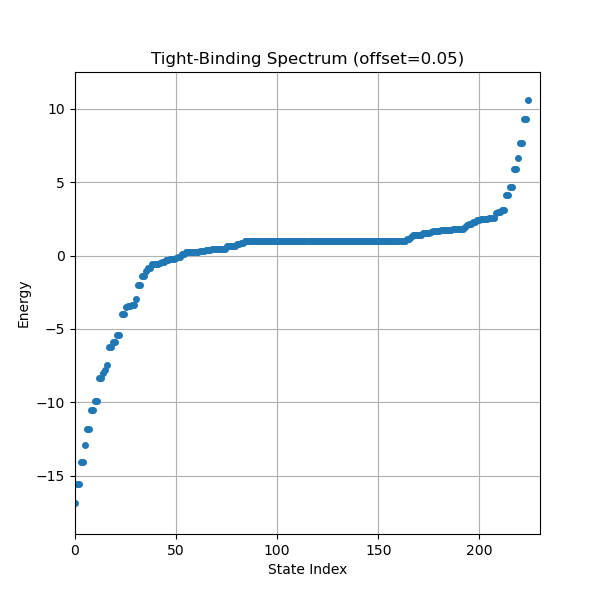

In [36]:
# ==========================================
# CELL 3: GIF of Energy Spectrum vs Offset
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

# -----------------------------
# Sweep configuration
# -----------------------------
offset_values = np.round(np.arange(0.05, 0.571, 0.01), 2)
gif_path = "energy_vs_state_offset.gif"

# Reuse existing model parameters from previous cells
a_val = a
Rmax_val = Rmax
cavity_radius_val = cavity_radius
c_val = c
t_val = t
onsite_val = onsite
cutoff_val = cutoff


def build_coords(offset_local):
    c4_basis_local = [
        (+offset_local, +offset_local),
        (+offset_local, -offset_local),
        (-offset_local, +offset_local),
        (-offset_local, -offset_local),
    ]

    c4_points_local = []
    for i_local in range(-Rmax_val, Rmax_val + 1):
        for j_local in range(-Rmax_val, Rmax_val + 1):
            for dx_local, dy_local in c4_basis_local:
                x_local = i_local * a_val + dx_local
                y_local = j_local * a_val + dy_local
                if np.sqrt(x_local**2 + y_local**2) < cavity_radius_val:
                    c4_points_local.append((x_local, y_local))

    extended_local = []
    for x_local, y_local in c4_points_local:
        r_local = np.sqrt(x_local**2 + y_local**2)
        theta_local = np.arctan2(y_local, x_local)
        if theta_local < 0:
            theta_local += 2 * np.pi
        extended_local.append((r_local, theta_local))
        if 0 <= theta_local < np.pi / 2:
            extended_local.append((r_local, theta_local + 2 * np.pi))

    c5_points_local = []
    for r_local, theta_local in extended_local:
        theta_new_local = (4 / 5) * theta_local
        x_local = r_local * np.cos(theta_new_local)
        y_local = r_local * np.sin(theta_new_local)
        if r_local < cavity_radius_val:
            c5_points_local.append((x_local, y_local))

    coords_local = np.array(c5_points_local)
    distances_local = np.linalg.norm(coords_local, axis=1)
    nearest_indices_local = np.argsort(distances_local)[:5]

    for idx_local in nearest_indices_local:
        r_local = distances_local[idx_local]
        theta_local = np.arctan2(coords_local[idx_local, 1], coords_local[idx_local, 0])
        r_new_local = (1 - c_val) * r_local
        coords_local[idx_local, 0] = r_new_local * np.cos(theta_local)
        coords_local[idx_local, 1] = r_new_local * np.sin(theta_local)

    return coords_local


def spectrum_from_coords(coords_local):
    n_local = len(coords_local)
    h_local = np.zeros((n_local, n_local))
    np.fill_diagonal(h_local, onsite_val)

    for i_local in range(n_local):
        for j_local in range(i_local + 1, n_local):
            dist_local = np.linalg.norm(coords_local[i_local] - coords_local[j_local])
            if dist_local < cutoff_val:
                h_local[i_local, j_local] = -t_val
                h_local[j_local, i_local] = -t_val

    energies_local, _ = eigh(h_local)
    return energies_local


# Precompute spectra for stable axis limits
all_energies = []
max_n = 0
for off in offset_values:
    coords_off = build_coords(off)
    energies_off = spectrum_from_coords(coords_off)
    all_energies.append(energies_off)
    max_n = max(max_n, len(energies_off))

y_min = min(np.min(e) for e in all_energies)
y_max = max(np.max(e) for e in all_energies)
y_pad = 0.05 * (y_max - y_min + 1e-12)

fig, ax = plt.subplots(figsize=(6, 6))
line, = ax.plot([], [], 'o', markersize=4)
title = ax.set_title("")
ax.set_xlabel("State Index")
ax.set_ylabel("Energy")
ax.grid(True)
ax.set_xlim(0, max_n)
ax.set_ylim(y_min - y_pad, y_max + y_pad)


def init():
    line.set_data([], [])
    title.set_text("")
    return line, title


def update(frame_idx):
    energies_frame = all_energies[frame_idx]
    x_frame = np.arange(len(energies_frame))
    line.set_data(x_frame, energies_frame)
    title.set_text(f"Tight-Binding Spectrum (offset={offset_values[frame_idx]:.2f})")
    return line, title


anim = FuncAnimation(
    fig,
    update,
    frames=len(offset_values),
    init_func=init,
    blit=True,
    interval=250,
    repeat=True,
    repeat_delay=1000,
 )

anim.save(gif_path, writer=PillowWriter(fps=4))
plt.close(fig)

print(f"Saved GIF: {gif_path}")
display(Image(filename=gif_path))